# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [52]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [53]:
# Inspect the shapes of the datasets
def print_data_shape():
    #print(f'data_shape info')
    print(f'X_train shape: {X_train.shape}')
    print(f'y_train shape: {y_train.shape}')
    print(f'X_test shape: {X_test.shape}')
    print(f'y_test shape: {y_test.shape}')

print_data_shape()

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train_original = y_train.copy()
y_test_original = y_test.copy()

num_classes = len(class_names)
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


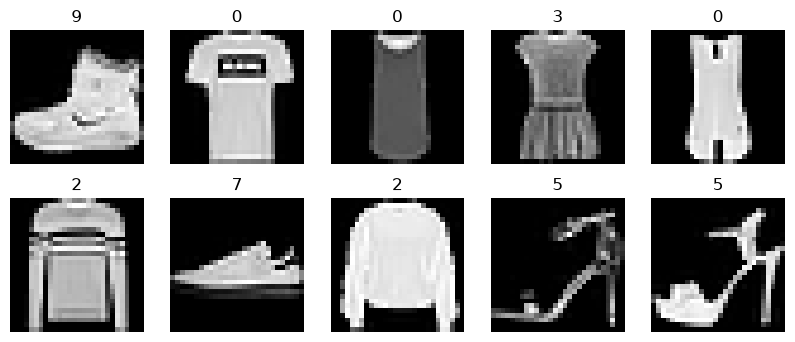

In [54]:
import matplotlib.pyplot as plt
# Verify the data looks as expected

plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train_original[i])
    plt.axis('off')

plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

The data looks as expected. The dataset consists of grayscale images of clothing items, such as shoes, shirts, dresses, and coats. Each image has a size of 28×28 pixels, which makes it a low-resolution dataset.

Because the images are small and grayscale, some fine details may be lost, and the lack of color information limits available features for classification. The dataset is relatively simple, with centered objects and clean backgrounds, so models trained on Fashion-MNIST may not generalize well to more complex real-world clothing images.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


c:\Users\simonc.IDEA\Desktop\DSI\deep_learning\deep-learning-env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6778 - loss: 1.0458 - val_accuracy: 0.7582 - val_loss: 0.7662
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7749 - loss: 0.7097 - val_accuracy: 0.7884 - val_loss: 0.6600
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7973 - loss: 0.6358 - val_accuracy: 0.8027 - val_loss: 0.6111
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8085 - loss: 0.5960 - val_accuracy: 0.8107 - val_loss: 0.5814
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8151 - loss: 0.5699 - val_accuracy: 0.8167 - val_loss: 0.5608
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8202 - loss: 0.5511 - val_accuracy: 0.8197 - val_loss: 0.5455
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8242 - loss: 0.5366 - val_accuracy: 0.8218 - val_loss: 0.5335
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8276 - loss: 0.5251 - val_accurac

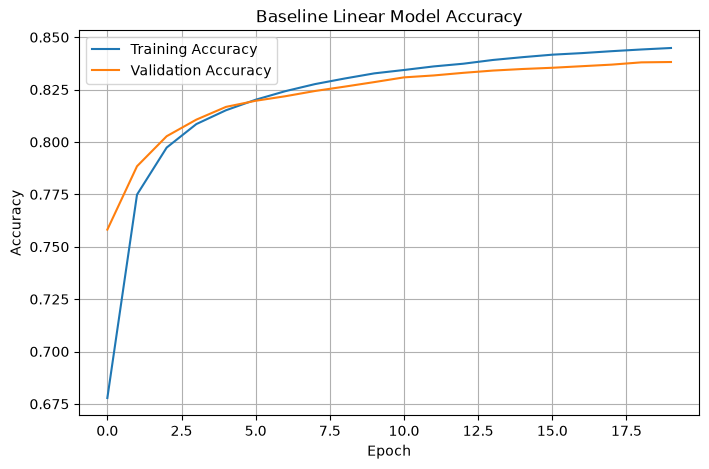

In [55]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

output_dim = num_classes

# Create a simple linear regression model
model = Sequential()

# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28))) # Flatten 28x28 images into a 784-dimensional vector
model.add(Dense(output_dim)) # Linear output layer (no activation)

print(y_train[0])
print(model.summary())

# Compile the model using `model.compile()`
from keras.optimizers import SGD
import tensorflow as tf

model.compile(optimizer=SGD(learning_rate=0.01),
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train the model with `model.fit()`
history = model.fit(X_train, y_train, epochs=20, batch_size=64,
                    validation_split=0.2) 

# Evaluate the model with `model.evaluate()`
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# report Test Results
print("\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot training and validation accuracy
import matplotlib.pyplot as plt

port_title = ('Port_title')
def plot_evaluate():
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(port_title)
    plt.legend()
    plt.grid(True)

    plt.show()

port_title =('Baseline Linear Model Accuracy')
plot_evaluate()


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

The baseline model achieved a test accuracy of approximately 82.85%, which is reasonable for a simple linear model and close to my expectations. Since the model consists of only a single Dense layer without hidden or convolutional layers, it can only learn linear relationships between the input pixels and the output classes. Although it cannot capture more complex image features, it provides a useful baseline for evaluating the performance improvements of more advanced models.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

(60000, 28, 28, 1)
(10000, 28, 28, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,770,634 (10.57 MB)

 Trainable params: 2,770,634 (10.57 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8491 - loss: 0.4185 - val_accuracy: 0.8842 - val_loss: 0.3259
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9011 - loss: 0.2711 - val_accuracy: 0.8963 - val_loss: 0.2919
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9224 - loss: 0.2155 - val_accuracy: 0.8989 - val_loss: 0.2881
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9373 - loss: 0.1740 - val_accuracy: 0.8979 - val_loss: 0.3058
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9509 - loss: 0.1387 - val_accuracy: 0.8987 - val_loss: 0.3200
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9609 - loss: 0.1107 - val_accuracy: 0.8971 - val_loss: 0.3505
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9702 - loss: 0.0890 - val_accuracy: 0.8988 - val_loss: 0.3659
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9753 - loss: 0.0732 - val_accurac

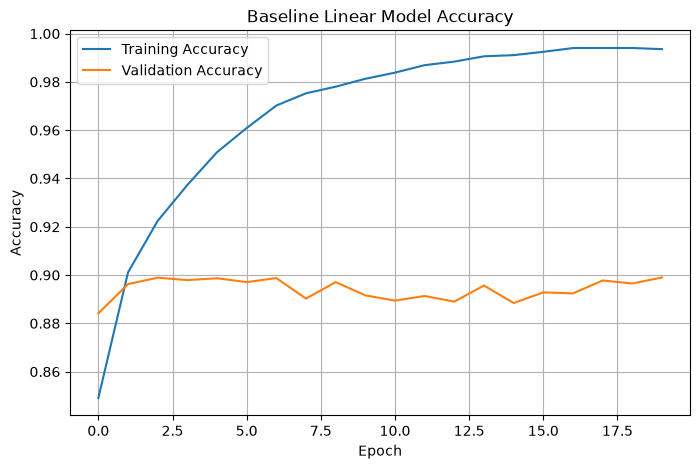

In [56]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras import backend as K

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)
print(X_test.shape)

# Plot training and validation accuracy
import matplotlib.pyplot as plt

# Create a simple CNN model
def create_cnn(kernel_size=(3,3)): #use_l2=False):
    model = Sequential()
    model.add(tf.keras.Input(shape=(28,28,1)))
    model.add(Conv2D(filters=32, kernel_size=kernel_size,                 
                    activation='relu', 
                    #kernel_regularizer=l2_reg
                    ))
    model.add(Flatten()) # Flatten feature maps into a vector
    model.add(Dense(128, activation='relu')) # Fully connected layer
    model.add(Dense(10, activation='softmax')) # Output layer

    # Compile the model
    model.compile(optimizer=Adam(),
                loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
                metrics=['accuracy'])
    return model

K.clear_session() # Reset model and optimizer

model = create_cnn()

# Display model architecture
print(model.summary())  
    
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2) 

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# collect the result
print("\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

plot_evaluate()



Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

The CNN model achieved approximately 89.25% test accuracy, about 6.4% higher than the baseline model's 82.85%. This improvement is due to the CNN's ability to automatically extract image features. The convolutional layer detects patterns such as edges and curves, enabling the model to learn more complex relationships than the baseline model, which only captures linear relationships between pixels and classes.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

(60000, 28, 28, 1)
(10000, 28, 28, 1)
Training: kernel= (3, 3) dropout= False


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 701,578 (2.68 MB)

 Trainable params: 701,578 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8423 - loss: 0.4426 - val_accuracy: 0.8849 - val_loss: 0.3286
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8952 - loss: 0.2890 - val_accuracy: 0.8984 - val_loss: 0.2887
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9111 - loss: 0.2414 - val_accuracy: 0.8998 - val_loss: 0.2812
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9245 - loss: 0.2052 - val_accuracy: 0.9050 - val_loss: 0.2741
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9371 - loss: 0.1758 - val_accuracy: 0.9084 - val_loss: 0.2716
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9463 - loss: 0.1502 - val_accuracy: 0.9080 - val_loss: 0.2723
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9535 - loss: 0.1301 - val_accuracy: 0.9068 - val_loss: 0.2987
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9603 - loss: 0.1115 - val_accurac

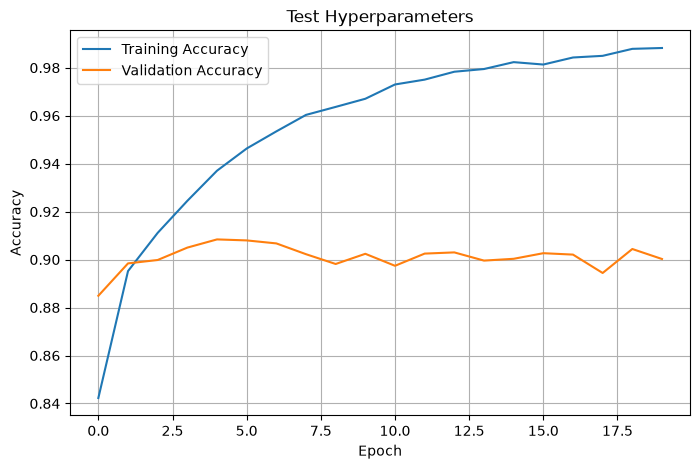

Training: kernel= (3, 3) dropout= True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 701,578 (2.68 MB)

 Trainable params: 701,578 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7370 - loss: 0.7400 - val_accuracy: 0.8664 - val_loss: 0.3922
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8401 - loss: 0.4684 - val_accuracy: 0.8855 - val_loss: 0.3233
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8631 - loss: 0.4070 - val_accuracy: 0.8932 - val_loss: 0.3017
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8729 - loss: 0.3728 - val_accuracy: 0.8996 - val_loss: 0.2783
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8812 - loss: 0.3457 - val_accuracy: 0.9029 - val_loss: 0.2747
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8901 - loss: 0.3211 - val_accuracy: 0.9057 - val_loss: 0.2677
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8950 - loss: 0.3050 - val_accuracy: 0.9073 - val_loss: 0.2580
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8980 - loss: 0.2945 - val_accurac

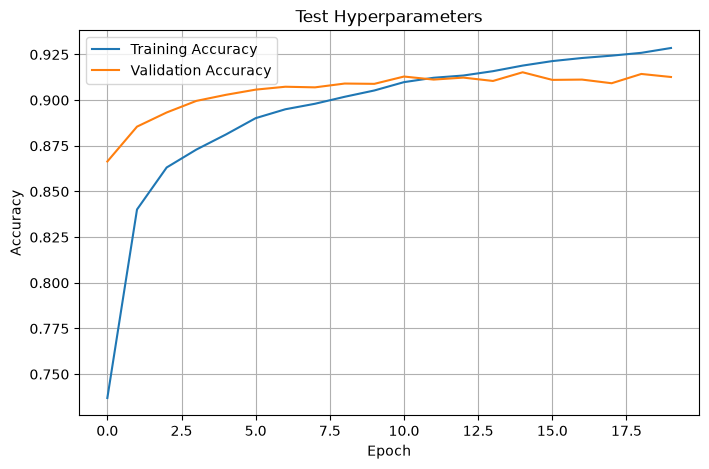

Training: kernel= (5, 5) dropout= False


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 599,690 (2.29 MB)

 Trainable params: 599,690 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8325 - loss: 0.4718 - val_accuracy: 0.8819 - val_loss: 0.3378
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8904 - loss: 0.3062 - val_accuracy: 0.8924 - val_loss: 0.3092
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9048 - loss: 0.2597 - val_accuracy: 0.8928 - val_loss: 0.3027
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9162 - loss: 0.2282 - val_accuracy: 0.8977 - val_loss: 0.2944
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9251 - loss: 0.2006 - val_accuracy: 0.9018 - val_loss: 0.2890
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9357 - loss: 0.1757 - val_accuracy: 0.9053 - val_loss: 0.2896
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9438 - loss: 0.1534 - val_accuracy: 0.9050 - val_loss: 0.3050
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9514 - loss: 0.1344 - val_accurac

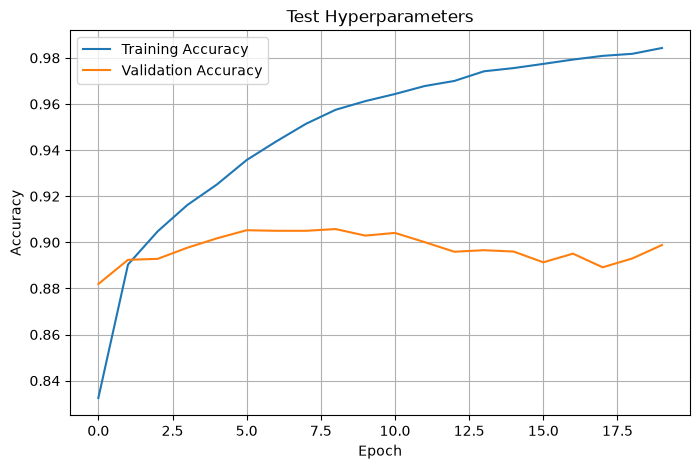

Training: kernel= (5, 5) dropout= True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 599,690 (2.29 MB)

 Trainable params: 599,690 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7296 - loss: 0.7625 - val_accuracy: 0.8597 - val_loss: 0.4045
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8349 - loss: 0.4788 - val_accuracy: 0.8840 - val_loss: 0.3310
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8576 - loss: 0.4088 - val_accuracy: 0.8901 - val_loss: 0.3032
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8707 - loss: 0.3726 - val_accuracy: 0.8932 - val_loss: 0.2871
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8809 - loss: 0.3442 - val_accuracy: 0.8953 - val_loss: 0.2859
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8858 - loss: 0.3274 - val_accuracy: 0.9037 - val_loss: 0.2695
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8919 - loss: 0.3066 - val_accuracy: 0.9050 - val_loss: 0.2617
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8952 - loss: 0.2929 - val_accurac

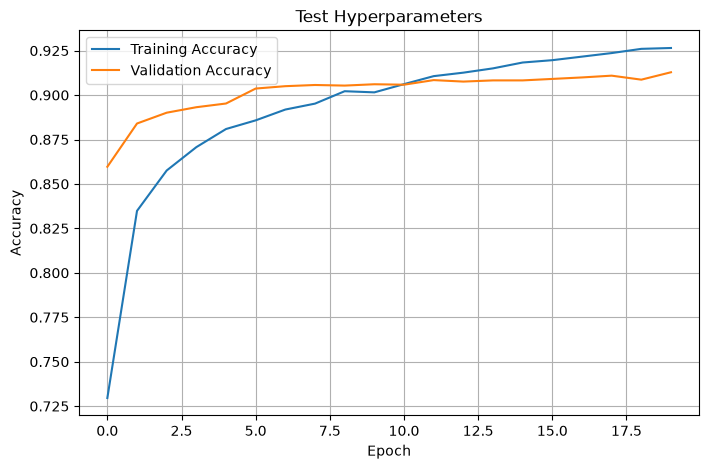

Training: kernel= (7, 7) dropout= False


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 22, 22, 32)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       495,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 506,250 (1.93 MB)

 Trainable params: 506,250 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8230 - loss: 0.4968 - val_accuracy: 0.8767 - val_loss: 0.3574
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8810 - loss: 0.3292 - val_accuracy: 0.8867 - val_loss: 0.3172
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8966 - loss: 0.2821 - val_accuracy: 0.8953 - val_loss: 0.2995
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9085 - loss: 0.2474 - val_accuracy: 0.8988 - val_loss: 0.2885
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9195 - loss: 0.2203 - val_accuracy: 0.8961 - val_loss: 0.3039
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9285 - loss: 0.1979 - val_accuracy: 0.9030 - val_loss: 0.2851
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9354 - loss: 0.1768 - val_accuracy: 0.9010 - val_loss: 0.2895
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9404 - loss: 0.1616 - val_accurac

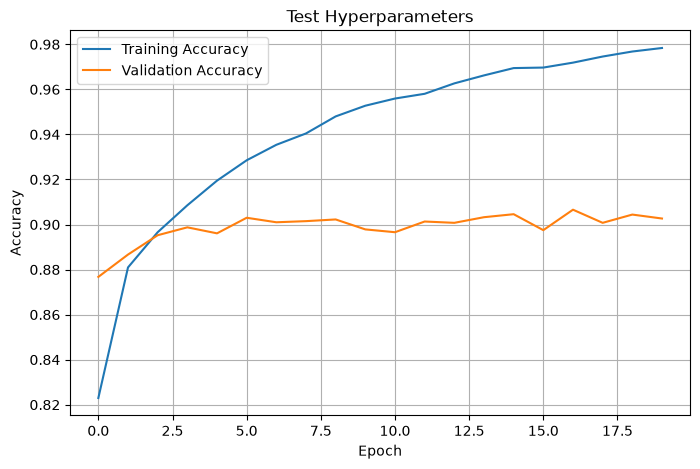

Training: kernel= (7, 7) dropout= True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 22, 22, 32)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       495,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 506,250 (1.93 MB)

 Trainable params: 506,250 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7192 - loss: 0.8056 - val_accuracy: 0.8551 - val_loss: 0.4332
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8253 - loss: 0.5077 - val_accuracy: 0.8743 - val_loss: 0.3584
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8500 - loss: 0.4399 - val_accuracy: 0.8844 - val_loss: 0.3282
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8635 - loss: 0.4031 - val_accuracy: 0.8894 - val_loss: 0.3100
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8709 - loss: 0.3753 - val_accuracy: 0.8955 - val_loss: 0.2953
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8789 - loss: 0.3560 - val_accuracy: 0.8921 - val_loss: 0.3004
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8839 - loss: 0.3357 - val_accuracy: 0.8977 - val_loss: 0.2905
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8880 - loss: 0.3206 - val_accurac

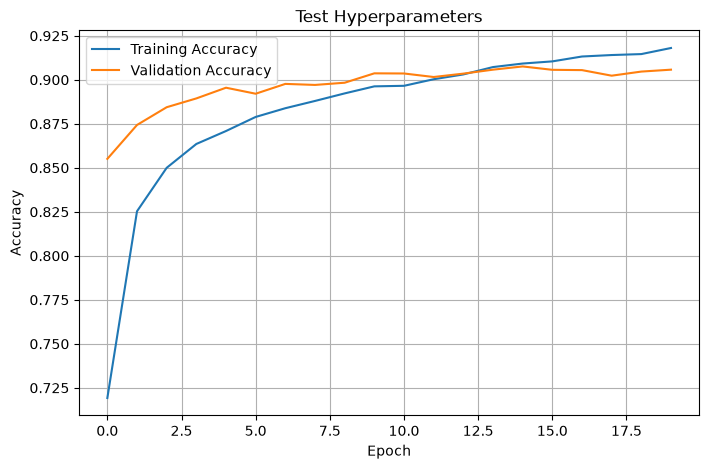

,Kernel Size,Dropout,Test Accuracy,Test Loss,Best Train,Best Validation
1,"(3, 3)",Yes,0.9123,0.284552,0.928542,0.915250
3,"(5, 5)",Yes,0.9083,0.292168,0.926479,0.912833
5,"(7, 7)",Yes,0.9045,0.289108,0.918063,0.907583
4,"(7, 7)",No,0.9011,0.486674,0.978375,0.906583
0,"(3, 3)",No,0.8995,0.588818,0.988229,0.908417
2,"(5, 5)",No,0.8959,0.548552,0.984292,0.905750


In [57]:
# A. Test Hyperparameters

from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras import backend as K
from keras.optimizers import SGD
import tensorflow as tf
import pandas as pd
import itertools
from itertools import product
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
import random
import numpy as np


# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)
print(X_test.shape)

# Plot training and validation accuracy
import matplotlib.pyplot as plt

seed = 42

tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Create a simple CNN model
def create_cnn(kernel_size=(3,3), use_dropout=True, l2_reg= None): 
  
    model = Sequential()
    model.add(tf.keras.Input(shape=(28,28,1)))
    model.add(Conv2D(filters=32, kernel_size=kernel_size,                 
                    activation='relu', 
                    kernel_regularizer=l2_reg
                    ))
    model.add(MaxPooling2D(pool_size=(2,2))) # Pooling layer
    model.add(Flatten()) # Flatten feature maps into a vector
    model.add(Dense(128, activation='relu',kernel_regularizer=l2_reg)) # Fully connected layer
    if use_dropout: 
        model.add(Dropout(0.5)) # Optional dropout
    model.add(Dense(64, activation='relu'))  # Hidden layer
    if use_dropout: 
        model.add(Dropout(0.5)) # Optional dropout
    model.add(Dense(10, activation='softmax')) # Output layer

    # Compile the model
    model.compile(optimizer=Adam(),
                loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
                metrics=['accuracy'])
    return model


# Experiment settings
kernel_sizes = [(3,3), (5,5), (7,7)]
dropout_options = [False, True]

experiments = [
    {
        "kernel_sizes": kernel,
        "dropout_options": dropout
    }
    for kernel, dropout in product(
        kernel_sizes,
        dropout_options
    )
]

port_title = ('Test Hyperparameters')

results = []


for exp in experiments:

    print(f"Training: kernel=",exp["kernel_sizes"], "dropout=", exp["dropout_options"])

    K.clear_session() # Reset model and optimizer

    model = create_cnn(
        kernel_size=exp["kernel_sizes"],
        use_dropout=exp["dropout_options"]
        )

    # Display model architecture
    print(model.summary())
    
    # Train the model
    history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2, verbose=1) 

    # Evaluate the model
    test_loss, test_accuracy = model.evaluate(X_test, y_test)

    best_val_acc = max(history.history['val_accuracy'])
    best_train_acc = max(history.history['accuracy'])

    # collect the result
    results.append({
        "Kernel Size": str(exp["kernel_sizes"]),
        "Dropout": "Yes" if exp["dropout_options"] else "No",
        "Test Accuracy": test_accuracy,
        "Test Loss": test_loss,
        "Best Train": best_train_acc,
        "Best Validation": best_val_acc,
        "Test Accuracy": test_accuracy
        })
    
    print("\nTest Results:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    plot_evaluate()

# Create result table
results_df = pd.DataFrame(results)

# Sort by accuracy
results_df = results_df.sort_values("Test Accuracy", ascending=False)

results_df


(60000, 28, 28, 1)
(10000, 28, 28, 1)
L2_option= <keras.src.regularizers.regularizers.L2 object at 0x000001761E17C590>


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 701,578 (2.68 MB)

 Trainable params: 701,578 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7340 - loss: 0.7870 - val_accuracy: 0.8679 - val_loss: 0.4269
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8362 - loss: 0.5263 - val_accuracy: 0.8805 - val_loss: 0.3896
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8533 - loss: 0.4858 - val_accuracy: 0.8897 - val_loss: 0.3720
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8668 - loss: 0.4525 - val_accuracy: 0.8903 - val_loss: 0.3632
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8722 - loss: 0.4406 - val_accuracy: 0.8981 - val_loss: 0.3513
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8759 - loss: 0.4303 - val_accuracy: 0.8960 - val_loss: 0.3564
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8794 - loss: 0.4154 - val_accuracy: 0.9010 - val_loss: 0.3463
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8827 - loss: 0.4062 - val_accurac

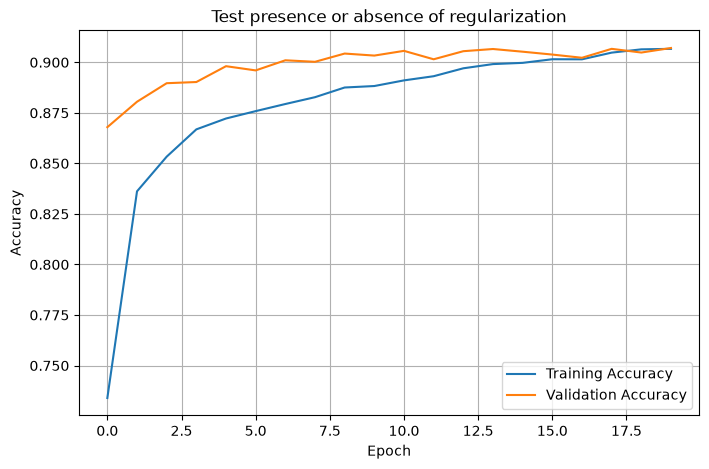

L2_option= None


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 701,578 (2.68 MB)

 Trainable params: 701,578 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7223 - loss: 0.7856 - val_accuracy: 0.8619 - val_loss: 0.4075
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8333 - loss: 0.4872 - val_accuracy: 0.8808 - val_loss: 0.3371
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8584 - loss: 0.4170 - val_accuracy: 0.8886 - val_loss: 0.3096
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8694 - loss: 0.3798 - val_accuracy: 0.8954 - val_loss: 0.2864
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8786 - loss: 0.3573 - val_accuracy: 0.8990 - val_loss: 0.2837
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8844 - loss: 0.3390 - val_accuracy: 0.9032 - val_loss: 0.2725
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8889 - loss: 0.3204 - val_accuracy: 0.9047 - val_loss: 0.2694
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8933 - loss: 0.3079 - val_accurac

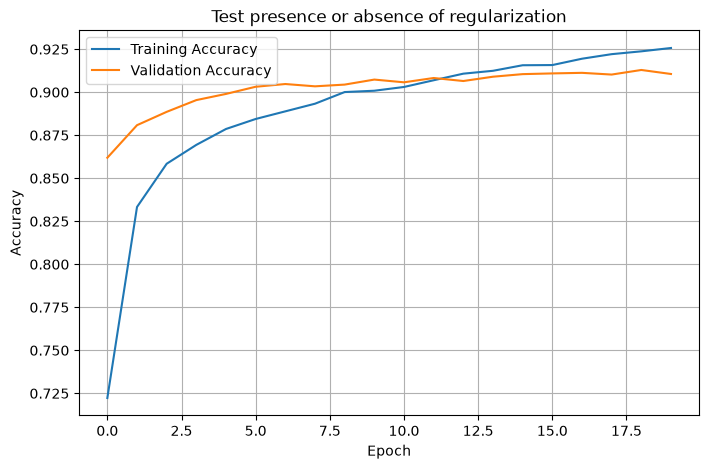

,L2 Regularization,Test Accuracy,Test Loss,Best Train,Best Validation
0,Yes,0.9064,0.359424,0.906667,0.907083
1,No,0.9064,0.298280,0.925687,0.912917


In [58]:
# B. Test presence or absence of regularization
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from keras import backend as K
from keras.optimizers import SGD
import tensorflow as tf
from keras.regularizers import l2
import pandas as pd


# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)
print(X_test.shape)

# Plot training and validation accuracy
import matplotlib.pyplot as plt

seed = 42

tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)


# Experiment settings
experiments = [
    {"l2_options": l2(0.0001)},
    {"l2_options":  None}
    ]

kernel_sizes = (3,3)
#kernel_sizes = [(5,5)]
#dropout_options = [False]
dropout_options = [True]

port_title = ('Test presence or absence of regularization')

results = []


for exp in experiments:

    print(f"L2_option=",exp["l2_options"])

    K.clear_session() # Reset model and optimizer

    model = create_cnn(
        kernel_size=kernel_sizes,
        use_dropout=dropout_options,
        l2_reg=exp["l2_options"]
    )
      
    # Display model architecture
    print(model.summary())
    
    # Train the model
    history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2, verbose=1) 

    # Evaluate the model
    test_loss, test_accuracy = model.evaluate(X_test, y_test)

    best_val_acc = max(history.history['val_accuracy'])
    best_train_acc = max(history.history['accuracy'])

    # collect the result
    results.append({
        "L2 Regularization": "Yes" if exp["l2_options"] else "No",
        "Test Accuracy": test_accuracy,
        "Test Loss": test_loss,
        "Best Train": best_train_acc,
        "Best Validation": best_val_acc,
        "Test Accuracy": test_accuracy
        })
    
    print("\nTest Results:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    plot_evaluate()

# Create result table
results_df = pd.DataFrame(results)

# Sort by accuracy
results_df = results_df.sort_values("Test Accuracy", ascending=False)

results_df


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

The CNN experiments show that kernel size, dropout, and L2 regularization affected model performance. The best result was achieved with a (3, 3) kernel and dropout enabled, reaching the highest test accuracy of 91.23% and the lowest test loss (0.2846). 

The smaller kernel likely captured useful local image features while using fewer parameters. Dropout improved generalization by reducing overfitting, as models without dropout had much higher training accuracy but lower test performance. L2 regularization reduced training accuracy but did not improve test accuracy in this experiment. 

Overall, the best combination was (3, 3) kernel size with dropout and no L2 regularization, providing the best balance between accuracy and generalization.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

(60000, 28, 28, 1)
(10000, 28, 28, 1)
Training: kernel= (3, 3) dropout= [True] L2_option= None


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 701,578 (2.68 MB)

 Trainable params: 701,578 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7327 - loss: 0.7540 - val_accuracy: 0.8643 - val_loss: 0.3825
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8376 - loss: 0.4703 - val_accuracy: 0.8845 - val_loss: 0.3263
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8596 - loss: 0.4141 - val_accuracy: 0.8921 - val_loss: 0.3019
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8712 - loss: 0.3793 - val_accuracy: 0.8965 - val_loss: 0.2887
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8796 - loss: 0.3497 - val_accuracy: 0.8977 - val_loss: 0.2782
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8832 - loss: 0.3391 - val_accuracy: 0.9015 - val_loss: 0.2727
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8885 - loss: 0.3157 - val_accuracy: 0.9068 - val_loss: 0.2638
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8937 - loss: 0.3030 - val_accurac

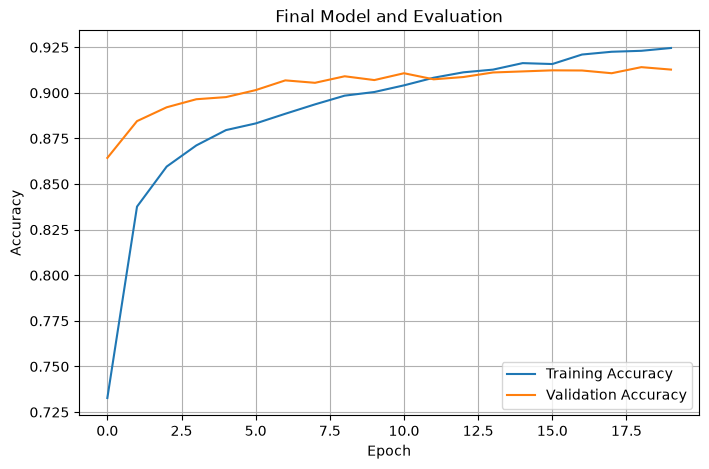

,Kernel Size,Dropout,L2 Regularization,Test Accuracy,Test Loss,Best Train,Best Validation
0,"(3, 3)",Yes,No,0.9109,0.291517,0.924583,0.914083


In [64]:
# Training Final Model and Evaluation

from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras import backend as K
from keras.optimizers import SGD
import tensorflow as tf
import pandas as pd
import itertools
from itertools import product
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
import random
import numpy as np


# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)
print(X_test.shape)

# Plot training and validation accuracy
import matplotlib.pyplot as plt

seed = 42

tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Create a simple CNN model
def create_cnn(kernel_size=(3,3), use_dropout=True, l2_reg= None): 
  
    model = Sequential()
    model.add(tf.keras.Input(shape=(28,28,1)))
    model.add(Conv2D(filters=32, kernel_size=kernel_size,                 
                    activation='relu', 
                    kernel_regularizer=l2_reg
                    ))
    model.add(MaxPooling2D(pool_size=(2,2))) # Pooling layer
    model.add(Flatten()) # Flatten feature maps into a vector
    model.add(Dense(128, activation='relu',kernel_regularizer=l2_reg)) # Fully connected layer
    if use_dropout: 
        model.add(Dropout(0.5)) # Optional dropout
    model.add(Dense(64, activation='relu'))  # Hidden layer
    if use_dropout: 
        model.add(Dropout(0.5)) # Optional dropout
    model.add(Dense(10, activation='softmax')) # Output layer

    # Compile the model
    model.compile(optimizer=Adam(),
                loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
                metrics=['accuracy'])
    return model


# Final settings
kernel_sizes = (3,3)
dropout_options = [True]
l2_options = None

port_title = ('Final Model and Evaluation')

results = []


print(f"Training: kernel=",kernel_sizes, "dropout=", dropout_options,"L2_option=", l2_options)

K.clear_session() # Reset model and optimizer

# model = create_cnn(
#     kernel_size=exp["kernel_sizes"],
#     use_dropout=exp["dropout_options"]
#     l2_reg=exp["l2_options"]
# )
model = create_cnn(
    kernel_size=kernel_sizes,
    use_dropout=dropout_options,
    l2_reg=l2_options
)

# Display model architecture
print(model.summary())

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2, verbose=1) 

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

best_val_acc = max(history.history['val_accuracy'])
best_train_acc = max(history.history['accuracy'])

# collect the result
results.append({
    "Kernel Size": kernel_sizes,
    "Dropout": "Yes" if "dropout_options" else "No",
    "L2 Regularization": "Yes" if l2_options else "No",
    "Test Accuracy": test_accuracy,
    "Test Loss": test_loss,
    "Best Train": best_train_acc,
    "Best Validation": best_val_acc,
    "Test Accuracy": test_accuracy
    })

print("\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

plot_evaluate()

# Create result table
results_df = pd.DataFrame(results)

# Sort by accuracy
results_df = results_df.sort_values("Test Accuracy", ascending=False)

results_df

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

The final CNN model achieved a test accuracy of 91.09%, improving significantly over the baseline model (82.85%) and performing similarly to the best CNN model (91.23%). The use of dropout helped reduce overfitting and improve generalization, while the (3, 3) kernel size effectively extracted image features with fewer parameters.

Further improvements could be explored by testing additional convolutional layers, different filter sizes, learning rates, batch normalization, data augmentation, and different dropout rates.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.